<h1>Monstro da Semana 7: Wyvern</h1>

<h4><i>- Bruno Bini Camargo</i></h4>

<h2>Introdução</h2>

A **distribuição uniforme contínua** é uma distribuição utilizada para modelar cenários em que uma variável aleatória tem a mesma probabilidade de assumir qualquer valor dentro de um intervalo bem definido $[a, b]$. A sua função de densidade de probabilidade é constante ao longo de todo o intervalo, garantindo que subintervalos de mesmo tamanho possuam probabilidades idênticas.

Já a **distribuição normal** descreve fenômenos em que os dados se agrupam de forma simétrica em torno de um valor central, denominado média ($\mu$), com a dispersão controlada pelo desvio padrão ($\sigma$). Caracterizada pela sua curva em formato de sino, é uma das distribuições mais importantes para representar processos com variações naturais.

Além disso, a **função de distribuição acumulada (CDF)** indica a probabilidade de uma variável aleatória assumir um valor menor ou igual a um determinado ponto $x$, ou seja, $P(X \le x)$. A partir do complemento da CDF (1 - CDF), é possível determinar a probabilidade de a variável assumir valores estritamente superiores a esse limite.

Estes conceitos serão aplicados nos exercícios a seguir.

<h2>Desenvolvimento</h2>

<h3>Enunciado</h3>

As reuniões da Cúpula de Ciência, Tecnologia e Encantamentos do reino de Lumi acontecem de terça‑feira, tendo início às 12:30.

A feiticeira $A$ chega nessa reunião entre 12:30 e 12:35 seguindo uma distribuição uniforme contínua de probabilidade.

O arcano $B$ chega nessa reunião seguindo uma distribuição normal de probabilidade com média 12:33 e desvio padrão de 0.5 minuto.

A chegada dos magos $A$ e $B$ são eventos independentes.

Qual é a probabilidade de que os místicos $A$ e $B$ irão perder os 2 primeiros minutos da reunião da Cúpula na próxima terça‑feira?

*Resolva este problema de forma numérica usando código* e guie o leitor durante todo o processo.

**Dica:** Quem sabe, representar os horários de outra maneira possa ajudar! Deixe claro para o leitor qualquer conversão que seja realizada.

<h3>Resolução</h3>

Primeiramente, vamos adotar a dica dada pelo enunciado e representar os horários como o tempo $T$ em minutos decorridos a partir do início da reunião (12:30):
- 12:30 $\rightarrow T = 0$ min
- 12:32 $\rightarrow T = 2$ min (limite dos 2 primeiros minutos)
- 12:33 $\rightarrow T = 3$ min (média da chegada do arcano $B$)
- 12:35 $\rightarrow T = 5$ min (limite superior da feiticeira $A$)

In [1]:
tempo_limite = 2.0

Segundo o enunciado, a feiticeira A segue uma distribuição uniforme contínua no intervalo $[0, 5]$: 
$$A \sim \mathcal{U}(0, 5)$$

In [2]:
import numpy as np
import scipy.stats as stats

a_min, a_max = 0.0, 5.0

Além disso, o arcano B segue uma distribuição normal de média $\mu = 3$ min e desvio-padrão $\sigma = 0,5$ min:$$B \sim \mathcal{N}(\mu = 3, \sigma^2 = 0,5^2)$$

In [3]:
b_media, b_desvio = 3.0, 0.5

Como as chegadas são independentes, podemos calcular primeiro a probabilidade de a feiticeira $A$ chegar após o tempo limite de $2$ minutos ($T > 2$), utilizando a Função de Distribuição Acumulada (CDF) da distribuição uniforme:

In [4]:
prob_A = 1 - stats.uniform.cdf(tempo_limite, loc=a_min, scale=a_max - a_min)
print(f"Probabilidade de a feiticeira A perder os 2 primeiros minutos: {prob_A:.4f} ({prob_A*100:.2f}%)")

Probabilidade de a feiticeira A perder os 2 primeiros minutos: 0.6000 (60.00%)


O gráfico abaixo apresenta a distribuição:

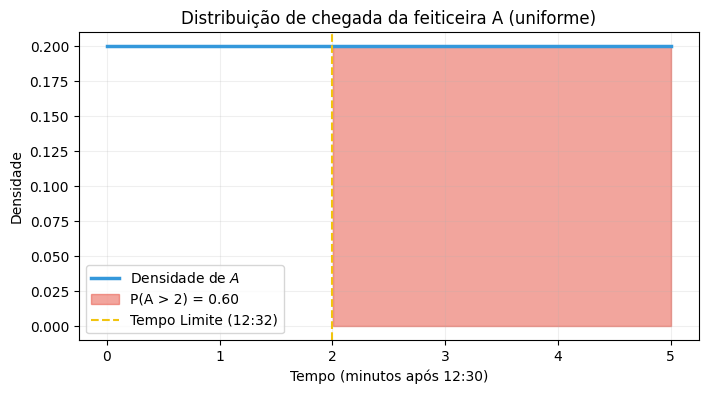

In [5]:
import matplotlib.pyplot as plt

x = np.linspace(a_min, a_max, 500)

plt.figure(figsize=(8, 4))
pdf_A = stats.uniform.pdf(x, loc=a_min, scale=a_max - a_min)
plt.plot(x, pdf_A, label='Densidade de $A$', color='#3498db', lw=2.5)

plt.fill_between(x, pdf_A, where=(x > tempo_limite), color='#e74c3c', alpha=0.5, label=f'P(A > 2) = {prob_A:.2f}')
plt.axvline(tempo_limite, color='#f1c40f', linestyle='--', label='Tempo Limite (12:32)')

plt.title('Distribuição de chegada da feiticeira A (uniforme)')
plt.xlabel('Tempo (minutos após 12:30)')
plt.ylabel('Densidade')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

No gráfico acima, a linha azul contínua representa a função de densidade de probabilidade $f(x) = 0{,}20$, que permanece constante ao longo de todo o intervalo de $0$ a $5$ minutos (12:30 às 12:35). A linha tracejada amarela indica o tempo limite de $T = 2$ minutos (12:32). A área sombreada em vermelho à direita dessa linha corresponde ao intervalo de atraso ($T > 2$). 

Como a área total sob a curva é igual a $1$, a região destacada representa exatamente $60\%$ da área total do retângulo, confirmando visualmente que $P(A > 2) = 0{,}60$.

Dando continuidade à resolução do problema, vamos calcular a probabilidade de o arcano $B$ também chegar após $2$ minutos ($T > 2$), utilizando a CDF da distribuição normal:

In [6]:
prob_B = 1 - stats.norm.cdf(tempo_limite, loc=b_media, scale=b_desvio)
print(f"Probabilidade de o arcano B perder os 2 primeiros minutos: {prob_B:.4f} ({prob_B*100:.2f}%)")

Probabilidade de o arcano B perder os 2 primeiros minutos: 0.9772 (97.72%)


Analisemos também a distribuição para o arcano B:

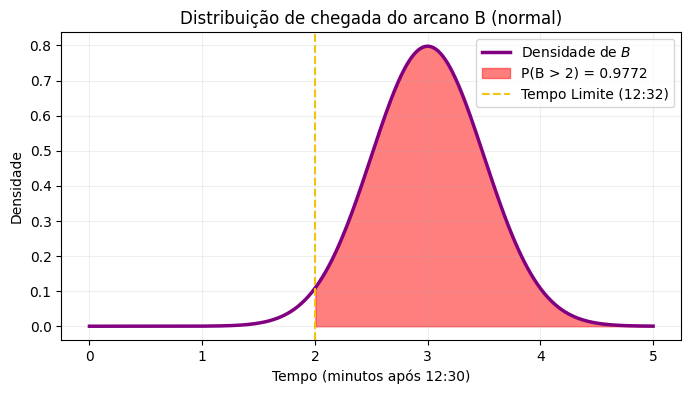

In [7]:
plt.figure(figsize=(8, 4))
pdf_B = stats.norm.pdf(x, loc=b_media, scale=b_desvio)
plt.plot(x, pdf_B, label='Densidade de $B$', color='purple', lw=2.5)

plt.fill_between(x, pdf_B, where=(x > tempo_limite), color='red', alpha=0.5, label=f'P(B > 2) = {prob_B:.4f}')
plt.axvline(tempo_limite, color='#f1c40f', linestyle='--', label='Tempo Limite (12:32)')

plt.title('Distribuição de chegada do arcano B (normal)')
plt.xlabel('Tempo (minutos após 12:30)')
plt.ylabel('Densidade')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

Aqui a curva simétrica em formato de sino possui o seu pico centrado na média $\mu = 3$ minutos (12:33). Como o desvio padrão é pequeno ($\sigma = 0.5$ minuto), a maior parte da massa de probabilidade está concentrada próxima à média. Ao traçarmos a linha limite de $T = 2$ minutos (12:32), nota-se que quase a totalidade da curva encontra-se à direita desse ponto. A área sombreada destaca essa região, demonstrando graficamente por que a probabilidade de atraso do arcano $B$ é tão elevada ($P(B > 2) \approx 97.72\%$).

Agora, sabendo que os eventos de chegada da feiticeira $A$ e do arcano $B$ são independentes, a probabilidade de ambos perderem os 2 primeiros minutos é o produto das probabilidades individuais:

In [8]:
prob_conjunta_exata = prob_A * prob_B
print(f"Probabilidade de ambos perderem os 2 primeiros minutos: {prob_conjunta_exata:.4f} ({prob_conjunta_exata*100:.2f}%)")

Probabilidade de ambos perderem os 2 primeiros minutos: 0.5863 (58.63%)


Portanto, percebe-se que a probabilidade de tanto a feiticeira A quanto o arcano B perderem os 2 primeiros minutos é de $58.63\%$.

Graficamente, podemos explorar isso:

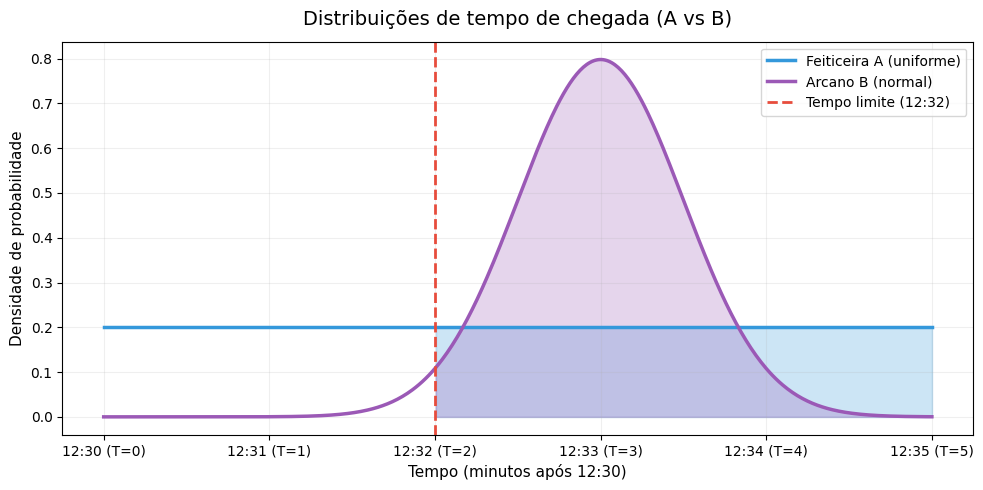

In [9]:
import matplotlib.pyplot as plt

plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 5))

x = np.linspace(a_min, a_max, 500)

pdf_A = stats.uniform.pdf(x, loc=a_min, scale=a_max - a_min)
ax.plot(x, pdf_A, label='Feiticeira A (uniforme)', color='#3498db', lw=2.5)
ax.fill_between(x, pdf_A, where=(x > tempo_limite), color='#3498db', alpha=0.25)

pdf_B = stats.norm.pdf(x, loc=b_media, scale=b_desvio)
ax.plot(x, pdf_B, label='Arcano B (normal)', color='#9b59b6', lw=2.5)
ax.fill_between(x, pdf_B, where=(x > tempo_limite), color='#9b59b6', alpha=0.25)

ax.axvline(tempo_limite, color='#e74c3c', linestyle='--', lw=2, label='Tempo limite (12:32)')

ax.set_title('Distribuições de tempo de chegada (A vs B)', fontsize=14, pad=12)
ax.set_xlabel('Tempo (minutos após 12:30)', fontsize=11)
ax.set_ylabel('Densidade de probabilidade', fontsize=11)
ax.set_xticks(np.arange(0, 6, 1))
ax.set_xticklabels(['12:30 (T=0)', '12:31 (T=1)', '12:32 (T=2)', '12:33 (T=3)', '12:34 (T=4)', '12:35 (T=5)'])
ax.grid(alpha=0.2)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

Ao sobrepor as duas distribuições em uma mesma escala temporal, é possível observar a diferença entre o comportamento de ambos os místicos. 

<h2>Conclusão</h2>

A partir da aplicação dos conceitos de probabilidade contínua, determinou-se que a probabilidade de a feiticeira $A$ e o arcano $B$ perderem os 2 primeiros minutos da reunião é de **$58.63\%$**.

A resolução mostrou que a feiticeira $A$, regida por uma **distribuição uniforme**, apresenta uma probabilidade constante de atraso de $60\%$. Já o arcano $B$, modelado por uma **distribuição normal** centrada em 12:33, possui uma chance de atraso de $97.72\%$. Como as chegadas são eventos independentes, o cálculo final obtido pela regra do produto ($0.60 \times 0.9772$) reflete com precisão a probabilidade da ocorrência simultânea dos dois atrasos.

<h2>Interação com a IA</h2>

A inteligência artificial foi utilizada ao longo do projeto como ferramenta de apoio na parte da programação, resolvendo dúvidas de sintaxe e realizando correções de erros de código (*debugging*).